C:\Users\HP\AppData\Roaming\Python\Python310\site-packages\numpy\lib\function_base.py:2853: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\HP\AppData\Roaming\Python\Python310\site-packages\numpy\lib\function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


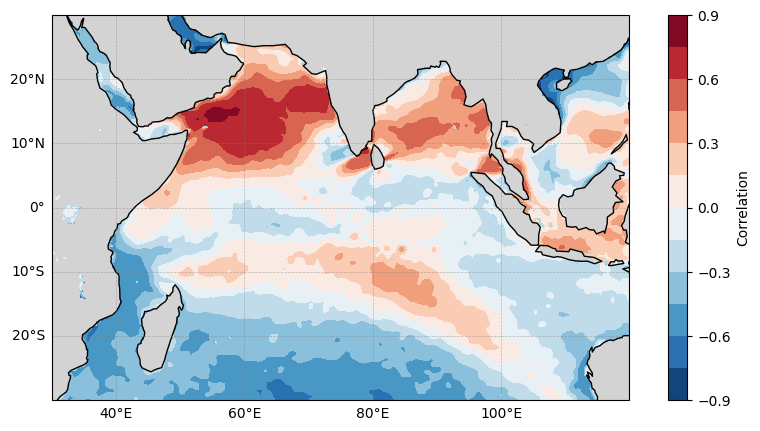

In [ ]:
from netCDF4 import Dataset
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# -------------------------------
# Load SST dataset
# -------------------------------
sst_file = "C:/Users/HP/Downloads/SST_1973_2022.nc"
sst_dataset = Dataset(sst_file, "r")

# Extract SST data (subset in time dimension)
sst = sst_dataset.variables['sst'][4:600, :, :]

# Extract latitude and longitude
lat_sst = sst_dataset.variables['latitude'][:]
lon_sst = sst_dataset.variables['longitude'][:]

# -------------------------------
# Load SLHF dataset
# -------------------------------
slhf_file = "C:/Users/HP/Downloads/SLHF_73_22.nc"
slhf_dataset = Dataset(slhf_file, "r")

# Extract SLHF data and multiply by -1 for consistency in sign convention
slhf = slhf_dataset.variables['slhf'][0:596, :, :] * -1

# Extract latitude and longitude
lat_slhf = slhf_dataset.variables['latitude'][:]
lon_slhf = slhf_dataset.variables['longitude'][:]

# -------------------------------
# Compute spatial correlation
# -------------------------------
# Initialize correlation array with same spatial shape as SST
correlation = np.zeros_like(sst[0, :, :])

# Loop over each grid point (lat, lon)
for i in range(len(lat_sst)):
    for j in range(len(lon_sst)):
        # Compute Pearson correlation between SST and SLHF time series
        corr = np.corrcoef(sst[:, i, j], slhf[:, i, j])
        
        # Store correlation coefficient
        correlation[i, j] = corr[0, 1]

# -------------------------------
# Create longitude-latitude grid
# -------------------------------
lon_grid, lat_grid = np.meshgrid(lon_slhf, lat_slhf)

# -------------------------------
# Plot using Cartopy
# -------------------------------
fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

# Set geographical extent (Tropical Indian Ocean region)
ax.set_extent([30, 120, -30, 30], crs=ccrs.PlateCarree())

# Add map features for visualization
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')

# -------------------------------
# Plot spatial correlation map
# -------------------------------
cs = ax.contourf(
    lon_grid, lat_grid, correlation,
    cmap='RdBu_r', levels=10,
    transform=ccrs.PlateCarree()
)

# -------------------------------
# Add colorbar
# -------------------------------
cbar = plt.colorbar(cs, orientation='vertical', pad=0.05)
cbar.set_label('Correlation')

# -------------------------------
# Add gridlines with lat/lon labels
# -------------------------------
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.5,
    color='gray',
    alpha=0.5,
    linestyle='--'
)

# Disable top and right labels for cleaner plot
gl.top_labels = False
gl.right_labels = False

# -------------------------------
# (Optional) Add title
# -------------------------------
# plt.title('Spatial Correlation between SST and SLHF')

# Display plot
plt.show()